<a href="https://colab.research.google.com/github/akshat280706/ML-Lab-Experiment/blob/main/241080009_akshat_ML_LAb5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from google.colab import files
uploaded=files.upload()

Saving electricity_cost_dataset.csv to electricity_cost_dataset (1).csv


In [11]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import(mean_squared_error, mean_absolute_error,r2_score)

df=pd.read_csv("electricity_cost_dataset.csv")

print("shape of the dataset: ")
print(df.shape)
print("\n")

#input
X=df.drop("electricity cost", axis=1)

#output
y=df["electricity cost"]

shape of the dataset: 
(10000, 9)





predicted vals:  [2654.7661067  1949.47923876 3770.68891478 1959.06376483 1873.21201208
 2180.954689   2896.47280801  854.15957041 3949.17263635 4664.12448455]

actual vals:  [2027. 1744. 4233. 1912. 1757. 2301. 3230. 1161. 4555. 4761.]

predictions: 
mse:  97383.69289251018
rmse:  312.06360392155665
mae:  245.68965395340388
r2:  0.9219364861500633


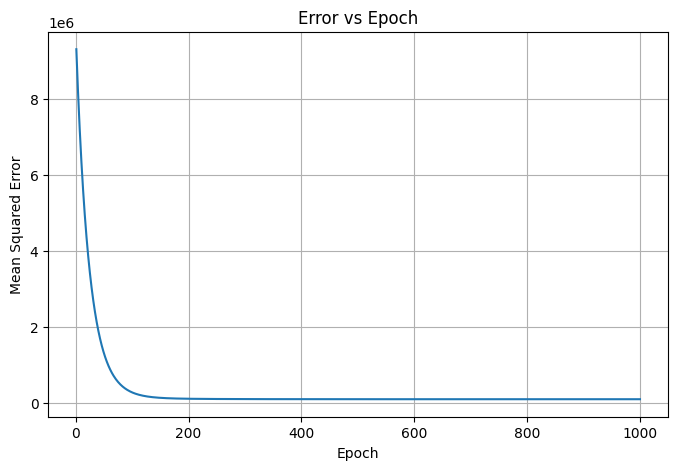


lib LR
MSE  : 97381.90152866754
RMSE : 312.0607337180818
MAE  : 245.65199402772697
R2   : 0.9219379221210353


In [12]:
#encoding

#using redHotEncoding to convert into 0/1
X=pd.get_dummies(X,columns=["structure type"], drop_first=True)
#drop_first as one true other false

#to store decimal
X=X.astype(float)

#spliting
X_train,X_test,y_train,y_test=train_test_split(
    X,y, test_size=0.2, random_state=42
)

#feature scaling with mean 0, SD 1
scaler=StandardScaler()
#calulate mean and sd and then standerdize
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test) #uses the same mean and SD

#convert into numpy array
y_train=y_train.values
y_test=y_test.values


n_samples=X_train.shape[0] #no of traiing rows
n_features=X_train.shape[1] #col

#how much it contributes
weights=np.zeros(n_features) #array el 0

bias=0 #constant added to prediction

learning_rate=0.01
epochs=1000 #how much times model willl go through training

error_history=[] #store error after every epoch

#gradient descent
for i in range(epochs):

  #prediction
  predictions=np.dot(X_train, weights)+bias
  error=predictions-y_train

  #mean square error(how bad model is performing)
  mse=np.mean(error**2)
  error_history.append(mse)

  #gradient cal(how much weight should change)
  #taking the derivative of mse
  dw=(2/n_samples)*np.dot(X_train.T,error)

  #bias gradient(how should bias change)
  db=(2/n_samples)*np.sum(error)

  weights=weights-learning_rate*dw
  bias=bias-learning_rate*db


#callculating actual predictions
predictions=np.dot(X_test, weights)+bias

print("\npredicted vals: ", predictions[:10]) #only first 10
print("\nactual vals: ", y_test[:10])


#performance
mse=mean_squared_error(y_test,predictions)
rmse=np.sqrt(mse)
mae=mean_absolute_error(y_test,predictions)
r2=r2_score(y_test, predictions)

print("\npredictions: ")
print("mse: ",mse)
print("rmse: ",rmse)
print("mae: ",mae)
print("r2: ",r2)

#graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1),error_history)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Error vs Epoch")
plt.grid()
plt.show()

#lib
library_model = LinearRegression()

library_model.fit(X_train, y_train)
library_prediction = library_model.predict(X_test)
library_mse = mean_squared_error(y_test,library_prediction)
library_rmse = np.sqrt(library_mse)
library_mae = mean_absolute_error(y_test,library_prediction)
library_r2 = r2_score(y_test,library_prediction)

print("\nlib LR")

print("MSE  :", library_mse)
print("RMSE :", library_rmse)
print("MAE  :", library_mae)
print("R2   :", library_r2)

In [ ]:
print("\n missing values: ")
print(df.isnull().sum())



 missing values: 
site area               0
structure type          0
water consumption       0
recycling rate          0
utilisation rate        0
air qality index        0
issue reolution time    0
resident count          0
electricity cost        0
dtype: int64


In [ ]:
print(df.head())

   site area structure type  water consumption  recycling rate  \
0       1360      Mixed-use             2519.0              69   
1       4272      Mixed-use             2324.0              50   
2       3592      Mixed-use             2701.0              20   
3        966    Residential             1000.0              13   
4       4926    Residential             5990.0              23   

   utilisation rate  air qality index  issue reolution time  resident count  \
0                52               188                     1              72   
1                76               165                    65             261   
2                94               198                    39             117   
3                60                74                     3              35   
4                65                32                    57             185   

   electricity cost  
0            1420.0  
1            3298.0  
2            3115.0  
3            1575.0  
4            4301.